In [ ]:
# 1) Drive'ı bağla
from google.colab import drive
drive.mount('/content/drive')

# 2) Kök yol
import os
ROOT = '/content/drive/MyDrive/Tubitak-2209a'
print("Kök var mı?:", os.path.isdir(ROOT), "->", ROOT)

# 3) Çıktı klasörünü oluştur (yoksa)
os.makedirs(os.path.join(ROOT, '03_spatial_analysis'), exist_ok=True)

# 4) 00_raw_data içindeki HER dosyayı boyutuyla listele (isimleri gözle görelim)
raw = os.path.join(ROOT, '00_raw_data')
print("\n--- 00_raw_data icerigi ---")
for f in sorted(os.listdir(raw)):
    p = os.path.join(raw, f)
    size_mb = os.path.getsize(p) / 1e6
    print(f"{size_mb:8.1f} MB  |  {f}")

# 5) Beklenen girdi dosyalarini tek tek dogrula
print("\n--- Girdi dosyasi kontrolu ---")
beklenen = {
    'scRNA referansi'   : '02_scRNA_analysis/scrna_filtered.h5ad',
    'CytoTRACE skorlari' : '02_scRNA_analysis/cytotrace2_epithelial_results.csv',
    'Bolge etiketleri'  : '01_processed_data/combined_with_regions.csv',
}
for ad, rel in beklenen.items():
    tam = os.path.join(ROOT, rel)
    print(f"{'VAR ' if os.path.isfile(tam) else 'YOK!':4} | {ad:20} | {rel}")

# 6) GPU teyidi
print("\n--- GPU ---")
os.system('nvidia-smi --query-gpu=name,memory.total --format=csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kök var mı?: True -> /content/drive/MyDrive/Tubitak-2209a

--- 00_raw_data icerigi ---
   558.3 MB  |  GSE176078_RAW.tar
   558.8 MB  |  GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz
     5.5 MB  |  GSE176078_Wu_etal_2021_bulkRNAseq_raw_counts.txt.gz
   155.7 MB  |  filtered_count_matrices (1).tar.gz
   457.7 MB  |  images.pdf
     0.2 MB  |  metadata.tar.gz
   252.9 MB  |  raw_count_matrices.tar.gz
    54.3 MB  |  spatial.tar.gz

--- Girdi dosyasi kontrolu ---
VAR  | scRNA referansi      | 02_scRNA_analysis/scrna_filtered.h5ad
VAR  | CytoTRACE skorlari   | 02_scRNA_analysis/cytotrace2_epithelial_results.csv
VAR  | Bolge etiketleri     | 01_processed_data/combined_with_regions.csv

--- GPU ---


0

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [ ]:
# scvi-colab: Colab'a uyumlu scvi-tools yiginini kurar
!pip install --quiet scvi-colab
from scvi_colab import install
install()

# cell2location'i GitHub'dan kur (tutorials ekstralariyla)
!pip install --quiet git+https://github.com/BayraktarLab/cell2location#egg=cell2location[tutorials]

print("\n=== KURULUM BITTI ===")
print(">>> SIMDI MANUEL RESTART: Runtime menusu -> Restart session <<<")

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           
DEPRECATION: git+https://github.com/BayraktarLab/cell2location#egg=cell2location[tutorials] contains an egg fragment with a non-PEP 508 name pip 25.0 will enforce this behaviour change. A possible replacement is to use the req @ url syntax, and remove the egg fragment. Discussion can be found at https://github.com/pypa/pip/issues/11617
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

=== KURULUM BITTI ===
>>> SIMDI MANUEL RESTART: Runtime menusu -> Restart session <<<


In [ ]:
# 1) torch hiz ayari — EN BASTA (notlardaki ~200x hizlanma icin kritik)
import torch
torch.set_float32_matmul_precision('high')

# 2) Kutuphaneleri import et (kurulum gercekten calisiyor mu)
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scvi
import cell2location

# 3) Surum numaralari (tekrarlanabilirlik icin kayit)
print("=== SURUMLER ===")
print("torch       :", torch.__version__)
print("numpy       :", np.__version__)
print("scanpy      :", sc.__version__)
print("anndata     :", ad.__version__)
print("scvi-tools  :", scvi.__version__)
print("cell2location:", cell2location.__version__)

# 4) GPU'yu PyTorch goruyor mu (nvidia-smi degil, torch'un kendisi)
print("\n=== GPU (torch tarafi) ===")
print("CUDA var mi :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU adi     :", torch.cuda.get_device_name(0))
    print("matmul prec :", torch.get_float32_matmul_precision())

# 5) Drive'i tekrar mount et (restart mount'u dusurur)
from google.colab import drive
drive.mount('/content/drive')
import os
ROOT = '/content/drive/MyDrive/Tubitak-2209a'
print("\nKok yol erisilebilir mi:", os.path.isdir(ROOT))

/usr/local/lib/python3.12/dist-packages/cell2location/models/base/_pyro_mixin.py:500: SyntaxWarning: invalid escape sequence '\.'
  prefix to add to column names (f'{summary_name}{name_prefix}_{site_name}_{self\.factor_names_}')


=== SURUMLER ===
torch       : 2.11.0+cu128
numpy       : 2.0.2
scanpy      : 1.12.2
anndata     : 0.12.19
scvi-tools  : 1.4.3
cell2location: 0.1.5

=== GPU (torch tarafi) ===
CUDA var mi : True
GPU adi     : NVIDIA A100-SXM4-40GB
matmul prec : high


/tmp/ipykernel_3248/3992273019.py:17: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy      :", sc.__version__)
/tmp/ipykernel_3248/3992273019.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata     :", ad.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Kok yol erisilebilir mi: True


In [ ]:
import tarfile, os

# tar.gz'i YEREL diske ac (/content/, Drive'a degil — Drive'i sismemek icin)
TARPATH = '/content/drive/MyDrive/Tubitak-2209a/00_raw_data/filtered_count_matrices (1).tar.gz'
EXTRACT_TO = '/content/visium_extracted'
os.makedirs(EXTRACT_TO, exist_ok=True)

with tarfile.open(TARPATH, 'r:gz') as tar:
    tar.extractall(EXTRACT_TO, filter='data')
print("Acildi ->", EXTRACT_TO)

# Klasor/dosya agacini goster (2 seviye)
print("\n=== ARSIV YAPISI ===")
for kok, klasorler, dosyalar in os.walk(EXTRACT_TO):
    seviye = kok.replace(EXTRACT_TO, '').count(os.sep)
    girinti = '  ' * seviye
    print(f"{girinti}{os.path.basename(kok)}/")
    for d in sorted(dosyalar):
        boyut_kb = os.path.getsize(os.path.join(kok, d)) / 1e3
        print(f"{girinti}  {boyut_kb:8.1f} KB  {d}")

Acildi -> /content/visium_extracted

=== ARSIV YAPISI ===
visium_extracted/
  filtered_count_matrices/
    CID4465_filtered_count_matrix/
          23.0 KB  barcodes.tsv.gz
         137.3 KB  features.tsv.gz
       58675.1 KB  matrix.mtx.gz
    CID4290_filtered_count_matrix/
          46.2 KB  barcodes.tsv.gz
         137.3 KB  features.tsv.gz
       91162.3 KB  matrix.mtx.gz
    CID44971_filtered_count_matrix/
          22.1 KB  barcodes.tsv.gz
         137.3 KB  features.tsv.gz
       49398.0 KB  matrix.mtx.gz
    CID4535_filtered_count_matrix/
          21.4 KB  barcodes.tsv.gz
         137.3 KB  features.tsv.gz
       56554.7 KB  matrix.mtx.gz
    1142243F_filtered_count_matrix/
          90.9 KB  barcodes.tsv.gz
         226.3 KB  features.tsv.gz
      158471.8 KB  matrix.mtx.gz
    1160920F_filtered_count_matrix/
          93.0 KB  barcodes.tsv.gz
         226.3 KB  features.tsv.gz
      213955.1 KB  matrix.mtx.gz


In [ ]:
import os, gzip

BASE = '/content/visium_extracted/filtered_count_matrices'
hastalar = sorted(os.listdir(BASE))
print("Hastalar:", hastalar, "\n")

# Bir ornek hasta uzerinde 3 dosyayi teshis et
ornek = os.path.join(BASE, hastalar[0])
print(f"=== TEŞHİS: {hastalar[0]} ===\n")

for dosya in ['barcodes.tsv.gz', 'features.tsv.gz', 'matrix.mtx.gz']:
    yol = os.path.join(ornek, dosya)
    with open(yol, 'rb') as f:
        ilk2 = f.read(2)
    # gzip dosyalari 0x1f 0x8b "magic number" ile baslar
    gercekten_gzip = (ilk2 == b'\x1f\x8b')
    print(f"{dosya:20} -> ilk 2 bayt: {ilk2}  |  gercekten gzip mi?: {gercekten_gzip}")

# features.tsv kac sutun? (once gzip dene, olmazsa duz metin oku)
print(f"\n=== features.tsv ilk satirlari ({hastalar[0]}) ===")
fyol = os.path.join(ornek, 'features.tsv.gz')
try:
    with gzip.open(fyol, 'rt') as f:
        satirlar = [f.readline().strip() for _ in range(3)]
    print("(gzip olarak okundu)")
except gzip.BadGzipFile:
    with open(fyol, 'rt') as f:
        satirlar = [f.readline().strip() for _ in range(3)]
    print("(DUZ METIN olarak okundu - uzanti yaniltici)")
for i, s in enumerate(satirlar):
    print(f"  satir {i}: {repr(s)}  ->  sutun sayisi: {len(s.split(chr(9)))}")

Hastalar: ['1142243F_filtered_count_matrix', '1160920F_filtered_count_matrix', 'CID4290_filtered_count_matrix', 'CID4465_filtered_count_matrix', 'CID44971_filtered_count_matrix', 'CID4535_filtered_count_matrix'] 

=== TEŞHİS: 1142243F_filtered_count_matrix ===

barcodes.tsv.gz      -> ilk 2 bayt: b'TA'  |  gercekten gzip mi?: False
features.tsv.gz      -> ilk 2 bayt: b'AL'  |  gercekten gzip mi?: False
matrix.mtx.gz        -> ilk 2 bayt: b'%%'  |  gercekten gzip mi?: False

=== features.tsv ilk satirlari (1142243F_filtered_count_matrix) ===
(DUZ METIN olarak okundu - uzanti yaniltici)
  satir 0: 'AL627309.1'  ->  sutun sayisi: 1
  satir 1: 'AL627309.3'  ->  sutun sayisi: 1
  satir 2: 'AL627309.5'  ->  sutun sayisi: 1


In [ ]:
import os, shutil, scipy.io, scipy.sparse as sp
import anndata as ad
import pandas as pd

BASE = '/content/visium_extracted/filtered_count_matrices'
hasta_klasor = '1142243F_filtered_count_matrix'
yol = os.path.join(BASE, hasta_klasor)

# --- .gz uzantisini kaldirarak /content/tmp_read/ 'e kopyala ---
# (dosyalar aslinda duz metin; uzantiyi atinca hicbir okuyucu gzip sanmaz)
tmp = '/content/tmp_read'
os.makedirs(tmp, exist_ok=True)
for src_ad, dst_ad in [('barcodes.tsv.gz', 'barcodes.tsv'),
                       ('features.tsv.gz', 'features.tsv'),
                       ('matrix.mtx.gz',   'matrix.mtx')]:
    shutil.copy(os.path.join(yol, src_ad), os.path.join(tmp, dst_ad))
print("Kopyalandi (.gz'siz):", os.listdir(tmp))

# --- Artik temiz oku ---
barcodes = pd.read_csv(os.path.join(tmp, 'barcodes.tsv'), header=None)[0].values
genes    = pd.read_csv(os.path.join(tmp, 'features.tsv'), header=None)[0].values
mtx      = scipy.io.mmread(os.path.join(tmp, 'matrix.mtx'))

print("\n=== HAM OKUMA ===")
print("barcodes (spot) sayisi :", len(barcodes))
print("genes sayisi           :", len(genes))
print("mtx ham shape          :", mtx.shape, "(satir, sutun)")

# --- MTX YONU ---
print("\n=== YON KONTROLU ===")
print("mtx.shape[0] == gen sayisi? :", mtx.shape[0] == len(genes))
print("mtx.shape[1] == spot sayisi?:", mtx.shape[1] == len(barcodes))

X = sp.csr_matrix(mtx.T)   # gen x spot -> spot x gen
print("\ntranspoze sonrasi X shape :", X.shape, "(spot, gen) olmali")

# --- AnnData ---
adata = ad.AnnData(X=X)
adata.obs_names = barcodes
adata.var_names = genes
print("\n=== AnnData ===")
print(adata)
print("var_names benzersiz mi? :", adata.var_names.is_unique)
print("obs_names benzersiz mi? :", adata.obs_names.is_unique)

Kopyalandi (.gz'siz): ['barcodes.tsv', 'features.tsv', 'matrix.mtx']

=== HAM OKUMA ===
barcodes (spot) sayisi : 4784
genes sayisi           : 28402
mtx ham shape          : (28402, 4784) (satir, sutun)

=== YON KONTROLU ===
mtx.shape[0] == gen sayisi? : True
mtx.shape[1] == spot sayisi?: True

transpoze sonrasi X shape : (4784, 28402) (spot, gen) olmali

=== AnnData ===
AnnData object with n_obs × n_vars = 4784 × 28402
var_names benzersiz mi? : True
obs_names benzersiz mi? : True


In [ ]:
import os, shutil, scipy.io, scipy.sparse as sp
import anndata as ad
import pandas as pd
import numpy as np

BASE = '/content/visium_extracted/filtered_count_matrices'
klasorler = sorted(os.listdir(BASE))

adatalar = []
print("=== HER HASTA OKUNUYOR ===")
for kl in klasorler:
    # klasor adindan patientid cikar: "1142243F_filtered_count_matrix" -> "1142243F"
    pid = kl.replace('_filtered_count_matrix', '')
    yol = os.path.join(BASE, kl)

    # .gz'siz gecici kopya (bu hastaya ozel klasor)
    tmp = f'/content/tmp_read_{pid}'
    os.makedirs(tmp, exist_ok=True)
    for s, d in [('barcodes.tsv.gz','barcodes.tsv'),
                 ('features.tsv.gz','features.tsv'),
                 ('matrix.mtx.gz','matrix.mtx')]:
        shutil.copy(os.path.join(yol, s), os.path.join(tmp, d))

    # oku
    bc  = pd.read_csv(os.path.join(tmp,'barcodes.tsv'), header=None)[0].values
    gn  = pd.read_csv(os.path.join(tmp,'features.tsv'), header=None)[0].values
    mtx = scipy.io.mmread(os.path.join(tmp,'matrix.mtx'))
    X   = sp.csr_matrix(mtx.T)   # spot x gen

    a = ad.AnnData(X=X)
    a.var_names = gn
    a.var_names_make_unique()              # tekrar eden gen adi olursa duzelt
    a.obs_names = [f'{pid}_{b}' for b in bc]  # patientid_ oneki (barkod cakismasi)
    a.obs['patientid'] = pid
    adatalar.append(a)
    print(f"{pid:10} -> spot: {a.n_obs:5}  gen: {a.n_vars:6}  var benzersiz: {a.var_names.is_unique}")

# --- BIRLESTIR: join='outer' (gen setleri farkli boyutta) ---
visium = ad.concat(adatalar, join='outer', label='batch_kaynak', fill_value=0)
print("\n=== BIRLESIK ===")
print(visium)
print("\nToplam spot:", visium.n_obs, "(Asama 0'da 15611 bekleniyor)")
print("Toplam gen (birlesim):", visium.n_vars)
print("\nHasta basina spot:")
print(visium.obs['patientid'].value_counts().sort_index())
print("\nobs_names benzersiz mi?:", visium.obs_names.is_unique)

=== HER HASTA OKUNUYOR ===
1142243F   -> spot:  4784  gen:  28402  var benzersiz: True
1160920F   -> spot:  4895  gen:  28402  var benzersiz: True
CID4290    -> spot:  2432  gen:  19237  var benzersiz: True
CID4465    -> spot:  1211  gen:  19237  var benzersiz: True
CID44971   -> spot:  1162  gen:  19237  var benzersiz: True
CID4535    -> spot:  1127  gen:  19237  var benzersiz: True

=== BIRLESIK ===
AnnData object with n_obs × n_vars = 15611 × 28925
    obs: 'patientid', 'batch_kaynak'

Toplam spot: 15611 (Asama 0'da 15611 bekleniyor)
Toplam gen (birlesim): 28925

Hasta basina spot:
patientid
1142243F    4784
1160920F    4895
CID4290     2432
CID4465     1211
CID44971    1162
CID4535     1127
Name: count, dtype: int64

obs_names benzersiz mi?: True


In [ ]:
import pandas as pd

REG = '/content/drive/MyDrive/Tubitak-2209a/01_processed_data/combined_with_regions.csv'
reg = pd.read_csv(REG)

print("=== combined_with_regions.csv YAPISI ===")
print("Boyut (satir, kolon):", reg.shape)
print("\nKolonlar:")
for c in reg.columns:
    print("  -", c)

print("\n=== ILK 3 SATIR ===")
print(reg.head(3).to_string())

# barcode kolonu patientid onekli mi, yoksa cıplak mı?
print("\n=== ANAHTAR KONTROLU ===")
if 'barcode' in reg.columns:
    print("Ornek barcode degerleri:")
    print(reg['barcode'].head(3).tolist())
if 'patientid' in reg.columns:
    print("Ornek patientid degerleri:", reg['patientid'].head(3).tolist())

# region_class ve tumor_region dagilimlari
for kol in ['region_class', 'tumor_region', 'analyze']:
    if kol in reg.columns:
        print(f"\n{kol} dagilimi:")
        print(reg[kol].value_counts(dropna=False))

=== combined_with_regions.csv YAPISI ===
Boyut (satir, kolon): (15611, 17)

Kolonlar:
  - barcode
  - nCount_RNA
  - nFeature_RNA
  - patientid
  - subtype
  - Classification
  - region_class
  - exclude_reason
  - array_row
  - array_col
  - pxl_row
  - pxl_col
  - analyze
  - n_nontumor_2ring
  - n_nontumor_3ring
  - n_valid_3ring
  - tumor_region

=== ILK 3 SATIR ===
              barcode  nCount_RNA  nFeature_RNA patientid subtype Classification region_class exclude_reason  array_row  array_col  pxl_row  pxl_col  analyze  n_nontumor_2ring  n_nontumor_3ring  n_valid_3ring tumor_region
0  TACCGATCCAACACTT-1        4073          2071  1142243F    TNBC       Artefact      exclude       Artefact        1.0        1.0   4510.0  12329.0    False               NaN               NaN            NaN          NaN
1  GATAAGGGACGATTAG-1        4628          2320  1142243F    TNBC       Artefact      exclude       Artefact        1.0        3.0   4511.0  12601.0    False               NaN        

In [ ]:
import pandas as pd
import numpy as np

# --- CSV'yi onekli anahtarla hazirla ---
REG = '/content/drive/MyDrive/Tubitak-2209a/01_processed_data/combined_with_regions.csv'
reg = pd.read_csv(REG)

# Visium obs_names ile ayni forma getir: patientid_barcode
reg['spot_key'] = reg['patientid'].astype(str) + '_' + reg['barcode'].astype(str)
reg = reg.set_index('spot_key')

print("=== ANAHTAR HIZALAMA ===")
print("CSV ornek anahtar :", reg.index[0])
print("Visium ornek obs  :", visium.obs_names[0])
# iki tarafin anahtar kumeleri ayni mi?
ortak = visium.obs_names.isin(reg.index)
print("Visium spotlarinin CSV'de karsiligi var mi (hepsi):", ortak.all())
print("Eslesen spot sayisi:", ortak.sum(), "/", visium.n_obs)

# --- obs'a baglanacak kolonlar ---
kolonlar = ['patientid','subtype','Classification','region_class','exclude_reason',
            'array_row','array_col','pxl_row','pxl_col','analyze',
            'n_nontumor_2ring','n_nontumor_3ring','n_valid_3ring','tumor_region']

# Visium sirasina gore hizala (.loc ile) ve obs'a yaz
reg_hizali = reg.loc[visium.obs_names, kolonlar]
for k in kolonlar:
    visium.obs[k] = reg_hizali[k].values

# eski gecici kolonu kaldir (artik patientid var)
if 'batch_kaynak' in visium.obs.columns:
    del visium.obs['batch_kaynak']

print("\n=== BAGLAMA SONRASI obs ===")
print(visium)
print("\nregion_class (Visium obs):")
print(visium.obs['region_class'].value_counts(dropna=False))
print("\ntumor_region (Visium obs):")
print(visium.obs['tumor_region'].value_counts(dropna=False))

# --- KAYDET ---
import os
OUT = '/content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis/visium_6patients_raw.h5ad'
visium.write_h5ad(OUT, compression='gzip')
print("\nKaydedildi ->", OUT)
print("Dosya boyutu (MB):", round(os.path.getsize(OUT)/1e6, 1))

# --- GERI OKU + DOGRULA ---
import anndata as ad
geri = ad.read_h5ad(OUT)
print("\n=== GERI OKUMA DOGRULAMA ===")
print("shape ayni mi:", geri.shape == visium.shape, "->", geri.shape)
print("obs kolonlari ayni mi:", list(geri.obs.columns) == list(visium.obs.columns))
print("matris toplami ayni mi:", np.isclose(geri.X.sum(), visium.X.sum()),
      "->", float(geri.X.sum()))

=== ANAHTAR HIZALAMA ===
CSV ornek anahtar : 1142243F_TACCGATCCAACACTT-1
Visium ornek obs  : 1142243F_TACCGATCCAACACTT-1
Visium spotlarinin CSV'de karsiligi var mi (hepsi): True
Eslesen spot sayisi: 15611 / 15611

=== BAGLAMA SONRASI obs ===
AnnData object with n_obs × n_vars = 15611 × 28925
    obs: 'patientid', 'subtype', 'Classification', 'region_class', 'exclude_reason', 'array_row', 'array_col', 'pxl_row', 'pxl_col', 'analyze', 'n_nontumor_2ring', 'n_nontumor_3ring', 'n_valid_3ring', 'tumor_region'

region_class (Visium obs):
region_class
tumor        11300
non_tumor     3152
exclude        874
in_situ        285
Name: count, dtype: int64

tumor_region (Visium obs):
tumor_region
core         7783
NaN          4311
uncertain    1785
front        1732
Name: count, dtype: int64

Kaydedildi -> /content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis/visium_6patients_raw.h5ad
Dosya boyutu (MB): 144.0

=== GERI OKUMA DOGRULAMA ===
shape ayni mi: True -> (15611, 28925)
obs kolonlari ayni

In [ ]:
import anndata as ad
import numpy as np

# scRNA referansini oku (Asama 2 ciktisi)
SC = '/content/drive/MyDrive/Tubitak-2209a/02_scRNA_analysis/scrna_filtered.h5ad'
ref = ad.read_h5ad(SC)

print("=== scRNA REFERANS ===")
print(ref)

# --- 1) HAM SAYIM MI? (cell2location ham/log-almamis ister) ---
print("\n=== HAM SAYIM KONTROLU ===")
X = ref.X
# ilk birkac sifir-olmayan degere bak: tam sayi mi, ondalikli mi?
ornek = X[:50].toarray() if hasattr(X, 'toarray') else X[:50]
sifir_olmayan = ornek[ornek > 0][:20]
print("Ornek sifir-olmayan degerler:", sifir_olmayan)
print("Hepsi tam sayi mi (ham sayim):", np.allclose(sifir_olmayan, np.round(sifir_olmayan)))
print("Max deger:", float(X.max()), "(log-normalize olsaydi ~10-15 civari olurdu)")

# --- 2) HUCRE TIPI + HASTA ETIKETLERI ---
print("\n=== ETIKET KONTROLU ===")
print("obs kolonlari:", list(ref.obs.columns))
print("\ncelltype_major dagilimi:")
print(ref.obs['celltype_major'].value_counts())
print("\norig.ident (hasta) sayisi:", ref.obs['orig.ident'].nunique())
print("Ornek hasta adlari:", ref.obs['orig.ident'].unique()[:5].tolist())

# --- 3) Boyut ozeti ---
print("\n=== OZET ===")
print("Hucre sayisi:", ref.n_obs)
print("Gen sayisi  :", ref.n_vars)
print("Hucre tipi sayisi:", ref.obs['celltype_major'].nunique())

=== scRNA REFERANS ===
AnnData object with n_obs × n_vars = 100064 × 29733
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major'

=== HAM SAYIM KONTROLU ===
Ornek sifir-olmayan degerler: [1. 1. 1. 1. 1. 1. 2. 1. 1. 8. 1. 1. 1. 4. 1. 1. 1. 1. 1. 1.]
Hepsi tam sayi mi (ham sayim): True
Max deger: 29831.0 (log-normalize olsaydi ~10-15 civari olurdu)

=== ETIKET KONTROLU ===
obs kolonlari: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']

celltype_major dagilimi:
celltype_major
T-cells              35214
Cancer Epithelial    24489
Myeloid               9675
Endothelial           7605
CAFs                  6573
PVL                   5423
Normal Epithelial     4355
Plasmablasts          3524
B-cells               3206
Name: count, dtype: int64

orig.ident (hasta) sayisi: 26
Ornek hasta adlari: ['CID3586', 'CID3921', 'CID45171', 'CID3838

Filtreleme oncesi gen sayisi: 29733


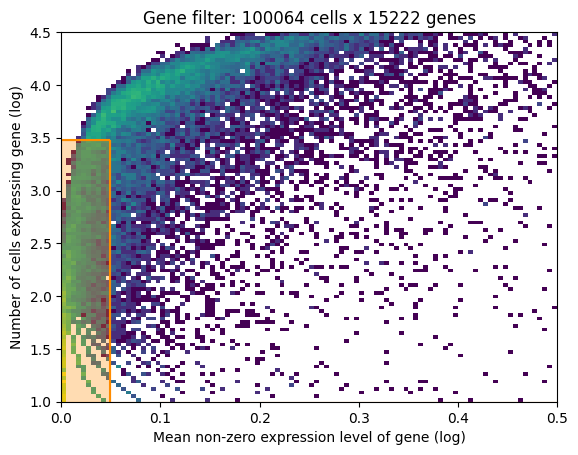


Secilen gen sayisi: 15222
Filtreleme sonrasi ref shape: (100064, 15222)


In [ ]:
import cell2location
from cell2location.utils.filtering import filter_genes
import matplotlib.pyplot as plt

print("Filtreleme oncesi gen sayisi:", ref.n_vars)

# cell2location'in onerdigi gen secimi
# cell_count_cutoff=5     : en az 5 hucrede gorulmeli
# cell_percentage_cutoff2=0.03 : hucrelerin en az %3'unde gorulmeli
# nonz_mean_cutoff=1.12   : sifir-olmayan hucrelerde ort. ifade esigi
selected = filter_genes(ref,
                        cell_count_cutoff=5,
                        cell_percentage_cutoff2=0.03,
                        nonz_mean_cutoff=1.12)
plt.show()

print("\nSecilen gen sayisi:", len(selected))

# Referansi secilen genlere indir
ref = ref[:, selected].copy()
print("Filtreleme sonrasi ref shape:", ref.shape)

In [ ]:
from cell2location.models import RegressionModel

# Veriyi modele tanit: hangi kolon batch, hangi kolon hucre tipi etiketi
RegressionModel.setup_anndata(
    adata=ref,
    batch_key='orig.ident',      # hasta/reaksiyon -> teknik farki modelle
    labels_key='celltype_major'  # 9 hucre tipi -> her tip icin imza ogren
)

# Modeli olustur
mod_ref = RegressionModel(ref)

# Kurulum ozetini goster
print(mod_ref.view_anndata_setup())

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Anndata setup with scvi-tools version 1.4.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'orig.ident',
│   'labels_key': 'celltype_major',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   26   │
│         n_cells          │ 100064 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   9    │
│          n_vars          │ 15222  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['orig.ident'] │  CID3586   │          0          │
│                         │  CID3838   │          1          │
│                         │  CID3921   │          2          │
│                         │  CID3941   │          3          │
│                         │  CID3946   │          4          │
│                         │  CID3948   │          5          │
│                         │  CID3963   │          6          │
│                         │  CID4040   │          7          │
│                         │  CID4066   │          8          │
│                         │  CID4067   │          9          │
│                         │  CID4290A  │         10          │
│                         │  CID4398   │         11          │
│                         │  CID4461   │         12          │
│                         │  CID4463   │         13          │
│                         │  CID4465   │         14          │
│                         │  CID4471   │         15          │
│                         │  CID4495   │         16          │
│                         │  CID4513   │         17          │
│                         │  CID4515   │         18          │
│                         │  CID4523   │         19          │
│                         │  CID4530N  │         20          │
│                         │  CID4535   │         21          │
│                         │  CID44041  │         22          │
│                         │  CID44971  │         23          │
│                         │  CID44991  │         24          │
│                         │  CID45171  │         25          │
└─────────────────────────┴────────────┴─────────────────────┘

                          labels State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location       ┃    Categories     ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['celltype_major'] │      B-cells      │          0          │
│                             │       CAFs        │          1          │
│                             │ Cancer Epithelial │          2          │
│                             │    Endothelial    │          3          │
│                             │      Myeloid      │          4          │
│                             │ Normal Epithelial │          5          │
│                             │        PVL        │          6          │
│                             │   Plasmablasts    │          7          │
│                             │      T-cells      │          8          │
└─────────────────────────────┴───────────────────┴─────────────────────┘

None


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:

INFO: `Trainer.fit` stopped: `max_epochs=250` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=250` reached.


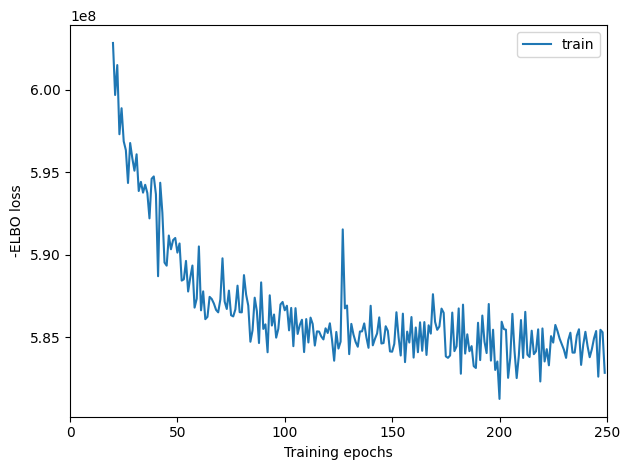

In [ ]:
import matplotlib.pyplot as plt

# CSR uyarisini gider (eğitim hizlanir) — sonra modeli YENIDEN kur
ref.X = ref.X.tocsr()

from cell2location.models import RegressionModel
RegressionModel.setup_anndata(
    adata=ref,
    batch_key='orig.ident',
    labels_key='celltype_major'
)
mod_ref = RegressionModel(ref)

# --- EGIT (250 epoch, GPU) ---
mod_ref.train(max_epochs=250)

# --- Egitim egrisini ciz (yakinsama kontrolu) ---
mod_ref.plot_history(20)   # ilk 20 epoch'u atlayarak ciz (baslangic gurultusu)
plt.show()

export_posterior bitti.


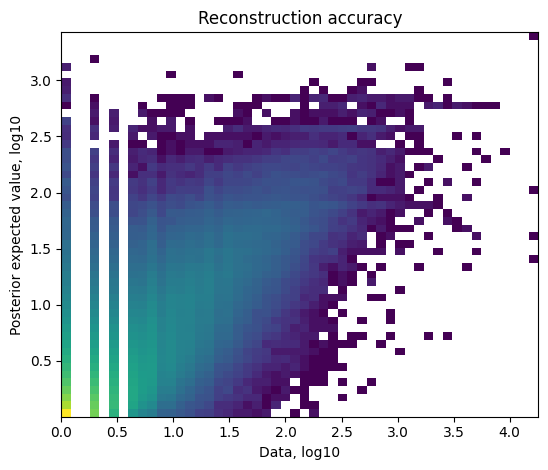

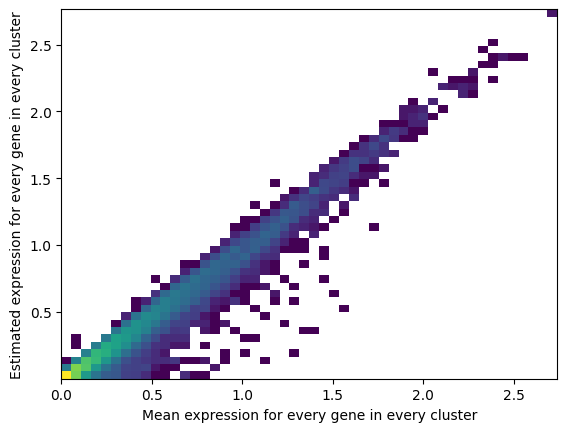


=== IMZA TABLOSU ===
Boyut (gen, hucre tipi): (15222, 9)
Hucre tipleri (sutunlar): ['B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'Plasmablasts', 'T-cells']

Ilk 5 gen, ilk birkac tip:
            B-cells   CAFs  Cancer Epithelial  Endothelial  Myeloid
FO538757.2    0.010  0.079              0.205        0.098    0.120
AP006222.2    0.003  0.056              0.073        0.035    0.044
SAMD11        0.000  0.083              0.017        0.003    0.000
NOC2L         0.058  0.136              0.907        0.167    0.121
PLEKHN1       0.000  0.003              0.077        0.002    0.001

Imza CSV kaydedildi.
Egitilmis referans .h5ad kaydedildi.
Kaydedilenler: /content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis/c2l_reference_signatures.csv


In [ ]:
import os
import matplotlib.pyplot as plt

# --- 1) Posterior'u cikar (ogrenilen dagilimi ozetle) ---
ref = mod_ref.export_posterior(
    ref,
    sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)
print("export_posterior bitti.")

# --- 2) Egitim kalitesi diagnostigi (opsiyonel gorsel) ---
mod_ref.plot_QC()
plt.show()

# --- 3) Imza tablosunu cikar (her gen x her hucre tipi) ---
# Once posterior'da hangi anahtar var, ona gore imzayi al
if 'means_per_cluster_mu_fg' in ref.varm.keys():
    inf_aver = ref.varm['means_per_cluster_mu_fg'][
        [f'means_per_cluster_mu_fg_{i}' for i in ref.uns['mod']['factor_names']]
    ].copy()
else:
    inf_aver = ref.var[
        [f'means_per_cluster_mu_fg_{i}' for i in ref.uns['mod']['factor_names']]
    ].copy()
# sutun adlarini temiz hucre tipi adlariyla degistir
inf_aver.columns = ref.uns['mod']['factor_names']

print("\n=== IMZA TABLOSU ===")
print("Boyut (gen, hucre tipi):", inf_aver.shape)
print("Hucre tipleri (sutunlar):", list(inf_aver.columns))
print("\nIlk 5 gen, ilk birkac tip:")
print(inf_aver.iloc[:5, :5].round(3))

# --- 4) KAYDET: imza CSV + egitilmis model+adata ---
OUTDIR = '/content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis'
inf_aver.to_csv(os.path.join(OUTDIR, 'c2l_reference_signatures.csv'))
print("\nImza CSV kaydedildi.")

ref.write_h5ad(os.path.join(OUTDIR, 'c2l_reference_trained.h5ad'), compression='gzip')
print("Egitilmis referans .h5ad kaydedildi.")
print("Kaydedilenler:", os.path.join(OUTDIR, 'c2l_reference_signatures.csv'))

In [ ]:
import anndata as ad
import numpy as np
import cell2location
from cell2location.models import Cell2location

# --- Visium'u ve imzayi yukle (kayittan, temiz baslangic) ---
OUTDIR = '/content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis'
visium = ad.read_h5ad(f'{OUTDIR}/visium_6patients_raw.h5ad')
print("Visium yuklendi:", visium.shape)

# imza tablosu (A asamasi ciktisi)
import pandas as pd
inf_aver = pd.read_csv(f'{OUTDIR}/c2l_reference_signatures.csv', index_col=0)
print("Imza tablosu:", inf_aver.shape)

# --- ORTAK GENLERE INDIR ---
# Visium genleri ile imza genlerinin kesisimi
ortak = [g for g in visium.var_names if g in inf_aver.index]
print("\nVisium gen:", visium.n_vars, "| Imza gen:", inf_aver.shape[0],
      "| ORTAK:", len(ortak))

visium = visium[:, ortak].copy()
inf_aver = inf_aver.loc[ortak].copy()
print("Ortak sonrasi -> Visium:", visium.shape, "| Imza:", inf_aver.shape)

# --- Visium matrisini CSR yap (hiz) ---
import scipy.sparse as sp
if not sp.isspmatrix_csr(visium.X):
    visium.X = visium.X.tocsr()

# --- Modeli kur ---
Cell2location.setup_anndata(adata=visium, batch_key='patientid')

mod_sp = Cell2location(
    visium,
    cell_state_df=inf_aver,       # A'dan gelen imzalar
    N_cells_per_location=8,       # spot basina beklenen ~hucre sayisi
    detection_alpha=20            # hastalar arasi yakalama farkini modelle
)
print("\n=== MODEL KURULDU ===")
print(mod_sp.view_anndata_setup())

Visium yuklendi: (15611, 28925)
Imza tablosu: (15222, 9)

Visium gen: 28925 | Imza gen: 15222 | ORTAK: 13919
Ortak sonrasi -> Visium: (15611, 13919) | Imza: (13919, 9)

=== MODEL KURULDU ===


Anndata setup with scvi-tools version 1.4.3.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'patientid',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   6   │
│         n_cells          │ 15611 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 13919 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['patientid'] │  1142243F  │          0          │
│                        │  1160920F  │          1          │
│                        │  CID4290   │          2          │
│                        │  CID4465   │          3          │
│                        │  CID4535   │          4          │
│                        │  CID44971  │          5          │
└────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

None


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:

INFO: `Trainer.fit` stopped: `max_epochs=20000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20000` reached.


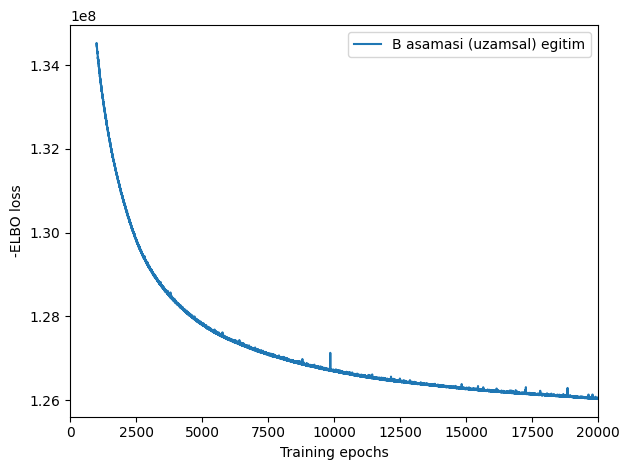


=== B ASAMASI EGITIMI BITTI ===


In [ ]:
import matplotlib.pyplot as plt

# --- B ASAMASI EGITIMI: 20000 epoch, TEK SEFERDE ---
# train() kaldigi yerden DEVAM ETMEZ; tek seferde makul sayi veriyoruz
mod_sp.train(
    max_epochs=20000,
    batch_size=None,   # tum spotlari birlikte kullan (bolme yok)
    train_size=1       # verinin tamami egitimde (ayirma yok)
)

# --- Yakinsama egrisi ---
# ilk 1000 epoch'u atlayarak ciz (baslangic gurultusu ezmesin)
mod_sp.plot_history(1000)
plt.legend(labels=['B asamasi (uzamsal) egitim'])
plt.show()

print("\n=== B ASAMASI EGITIMI BITTI ===")

In [ ]:
import os
OUTDIR = '/content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis'

# --- 1) EGITILMIS MODELI KAYDET (56 dk'yi kaybetmeyelim) ---
mod_sp.save(f'{OUTDIR}/c2l_spatial_model', overwrite=True)
print("Model kaydedildi ->", f'{OUTDIR}/c2l_spatial_model')

# --- 2) POSTERIOR'U CIKAR (ogrenilen bollugu ozetle) ---
visium = mod_sp.export_posterior(
    visium,
    sample_kwargs={'num_samples': 1000, 'batch_size': mod_sp.adata.n_obs}
)
print("export_posterior bitti.")

# --- 3) q05 BOLLUK TABLOSUNU AL ---
# q05 = posterior 5. yuzdelik = temkinli ("en az bu kadar") bolluk tahmini
abundance = visium.obsm['q05_cell_abundance_w_sf'].copy()
print("\n=== BOLLUK TABLOSU (q05) ===")
print("Boyut (spot, hucre tipi):", abundance.shape)
print("Sutun adlari:", list(abundance.columns))
print("\nIlk 3 spot:")
print(abundance.head(3).round(2))

# --- 4) modeli+sonuclari iceren adata'yi da kaydet ---
visium.write_h5ad(f'{OUTDIR}/c2l_spatial_mapped.h5ad', compression='gzip')
print("\nc2l_spatial_mapped.h5ad kaydedildi.")

Model kaydedildi -> /content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis/c2l_spatial_model


export_posterior bitti.

=== BOLLUK TABLOSU (q05) ===
Boyut (spot, hucre tipi): (15611, 9)
Sutun adlari: ['q05cell_abundance_w_sf_B-cells', 'q05cell_abundance_w_sf_CAFs', 'q05cell_abundance_w_sf_Cancer Epithelial', 'q05cell_abundance_w_sf_Endothelial', 'q05cell_abundance_w_sf_Myeloid', 'q05cell_abundance_w_sf_Normal Epithelial', 'q05cell_abundance_w_sf_PVL', 'q05cell_abundance_w_sf_Plasmablasts', 'q05cell_abundance_w_sf_T-cells']

Ilk 3 spot:
                             q05cell_abundance_w_sf_B-cells  \
1142243F_TACCGATCCAACACTT-1                            0.11   
1142243F_GATAAGGGACGATTAG-1                            0.01   
1142243F_TGTTGGCTGGCGGAAG-1                            0.00   

                             q05cell_abundance_w_sf_CAFs  \
1142243F_TACCGATCCAACACTT-1                         0.22   
1142243F_GATAAGGGACGATTAG-1                         0.16   
1142243F_TGTTGGCTGGCGGAAG-1                         0.19   

                             q05cell_abundance_w_sf_Cancer 

In [ ]:
import pandas as pd
import numpy as np

OUTDIR = '/content/drive/MyDrive/Tubitak-2209a/03_spatial_analysis'

# --- 1) Bollugu al, sutun adlarini temizle ---
abundance = visium.obsm['q05_cell_abundance_w_sf'].copy()
# uzun onekleri at: "q05cell_abundance_w_sf_CAFs" -> "CAFs"
abundance.columns = [c.replace('q05cell_abundance_w_sf_', '') for c in abundance.columns]

# --- 2) ORANA CEVIR: her satiri kendi toplamina bol (toplam=1) ---
oran = abundance.div(abundance.sum(axis=1), axis=0)
print("=== ORAN TABLOSU ===")
print("Boyut:", oran.shape)
print("Satir toplamlari 1 mi? (ornek ilk 5):")
print(oran.sum(axis=1).head().round(4).tolist())

# --- 3) obs bilgisini ekle ---
oran['patientid']    = visium.obs['patientid'].values
oran['region_class'] = visium.obs['region_class'].values
oran['tumor_region'] = visium.obs['tumor_region'].values
oran['analyze']      = visium.obs['analyze'].values

# --- 4) KAYDET (4a NIHAI CIKTI) ---
oran.to_csv(f'{OUTDIR}/spatial_celltype_composition.csv')
print("\nspatial_celltype_composition.csv kaydedildi.")

# --- 5) SANITY CHECK: Cancer Epithelial orani tumor vs non_tumor ---
print("\n=== SANITY CHECK: Cancer Epithelial orani ===")
for rc in ['tumor', 'non_tumor', 'in_situ']:
    mask = oran['region_class'] == rc
    ort = oran.loc[mask, 'Cancer Epithelial'].mean()
    print(f"  {rc:10} (n={mask.sum():5}) -> ort. Cancer Epithelial orani: {ort:.3f}")

print("\n=== CAFs orani (referans icin) ===")
for rc in ['tumor', 'non_tumor']:
    mask = oran['region_class'] == rc
    ort = oran.loc[mask, 'CAFs'].mean()
    print(f"  {rc:10} -> ort. CAFs orani: {ort:.3f}")

# tum tiplerin genel ortalamasi
print("\n=== TUM SPOTLARDA ORTALAMA KOMPOZISYON ===")
tip_kolonlari = [c for c in oran.columns if c not in ['patientid','region_class','tumor_region','analyze']]
print(oran[tip_kolonlari].mean().sort_values(ascending=False).round(3))

=== ORAN TABLOSU ===
Boyut: (15611, 9)
Satir toplamlari 1 mi? (ornek ilk 5):
[1.0, 1.0, 1.0, 1.0, 1.0]

spatial_celltype_composition.csv kaydedildi.

=== SANITY CHECK: Cancer Epithelial orani ===
  tumor      (n=11300) -> ort. Cancer Epithelial orani: 0.489
  non_tumor  (n= 3152) -> ort. Cancer Epithelial orani: 0.259
  in_situ    (n=  285) -> ort. Cancer Epithelial orani: 0.665

=== CAFs orani (referans icin) ===
  tumor      -> ort. CAFs orani: 0.100
  non_tumor  -> ort. CAFs orani: 0.078

=== TUM SPOTLARDA ORTALAMA KOMPOZISYON ===
Cancer Epithelial    0.447
Normal Epithelial    0.139
Myeloid              0.094
CAFs                 0.092
T-cells              0.090
B-cells              0.042
Endothelial          0.033
PVL                  0.032
Plasmablasts         0.030
dtype: float32


In [ ]:
import json

# Colab'daki mevcut notebook yolunu bulman gerek; genelde:
# /content/drive/MyDrive/Colab Notebooks/04a_deconvolution.ipynb
# ya da nereye kaydettiysen o yol
NB = '/content/drive/MyDrive/Colab Notebooks/04a_deconvolution.ipynb'  # <-- kendi yolunla degistir

with open(NB, 'r', encoding='utf-8') as f:
    nb = json.load(f)

# bozuk widget metadata'yi sil
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print("widgets metadata silindi.")
else:
    print("widgets metadata zaten yok - sorun baska olabilir.")

with open(NB, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)
print("Kaydedildi. Simdi tekrar push dene.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/04a_deconvolution.ipynb'

In [ ]:
import glob, os

# Drive'da tum .ipynb dosyalarini ara
print("=== Drive'daki .ipynb dosyalari ===")
bulunanlar = glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True)
for yol in sorted(bulunanlar):
    boyut_kb = os.path.getsize(yol) / 1e3
    print(f"{boyut_kb:8.1f} KB  |  {yol}")

if not bulunanlar:
    print("Hic .ipynb bulunamadi - notebook Drive'a kaydedilmemis olabilir.")

=== Drive'daki .ipynb dosyalari ===
